# 05 — v1.5-scalp-only execution sweep heatmaps

Visualise the 125-combo Stage-2a-extended sweep over
`passive_wait_ticks (pw)` × `aggressive_z_threshold (az)` × `max_step_size (ms)`.

Score (per row) = `mean_pnl_3day - 1.0 * std_pnl_3day`. Higher is better; everything in this sweep is negative.

Source: `R3/analysis/sweep_v1_5_results.json` (read-only here).
Context: `R3/analysis/agent_logs/P2_v1_5_extended_log.md`.

## 1. Setup — load sweep results

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while REPO.name and not (REPO / 'R3').exists():
    REPO = REPO.parent

RESULTS = REPO / 'R3/analysis/sweep_v1_5_results.json'
with open(RESULTS) as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
# Sanity-check schema and grid
assert len(df) == 125, f'expected 125 rows, got {len(df)}'
assert sorted(df['pw'].unique().tolist()) == [1, 2, 3, 5, 8]
assert sorted(df['az'].unique().tolist()) == [1.8, 2.0, 2.5, 3.0, 3.5]
assert sorted(df['ms'].unique().tolist()) == [5, 10, 15, 25, 40]
# Score is already in the JSON; recompute to verify
df['score_recalc'] = df['mean'] - df['stdev']
assert np.allclose(df['score'], df['score_recalc'])
df = df.drop(columns=['score_recalc'])
df.head()

,pw,az,ms,d0,d1,d2,mean,stdev,score,trades_total,label
0,8,3.5,5,-91.5,-482.0,-1643.0,-738.833333,807.007177,-1545.840510,368,v1.5-pw8-az3.5-ms5
1,8,3.5,15,-995.5,-880.5,-1689.5,-1188.500000,437.672252,-1626.172252,340,v1.5-pw8-az3.5-ms15
2,8,3.5,10,-278.5,-696.5,-1746.0,-907.000000,756.056711,-1663.056711,363,v1.5-pw8-az3.5-ms10
3,8,3.5,25,-1345.5,-739.5,-2119.5,-1401.500000,691.702248,-2093.202248,325,v1.5-pw8-az3.5-ms25
4,5,3.5,5,-241.0,-268.0,-2494.0,-1001.000000,1293.046403,-2294.046403,495,v1.5-pw5-az3.5-ms5


## 2. 2D heatmaps — best score over the third dimension

For each pair (e.g. pw × az), color = best (max) score across ms. This
answers: *"For this combo of two params, what's the best you could do by
tuning the third?"*

Diverging RdYlGn_r colormap, centered on 0. Score is negative everywhere;
darker red = worse, paler = closer to break-even. Cell labels are the
score rounded to nearest int.

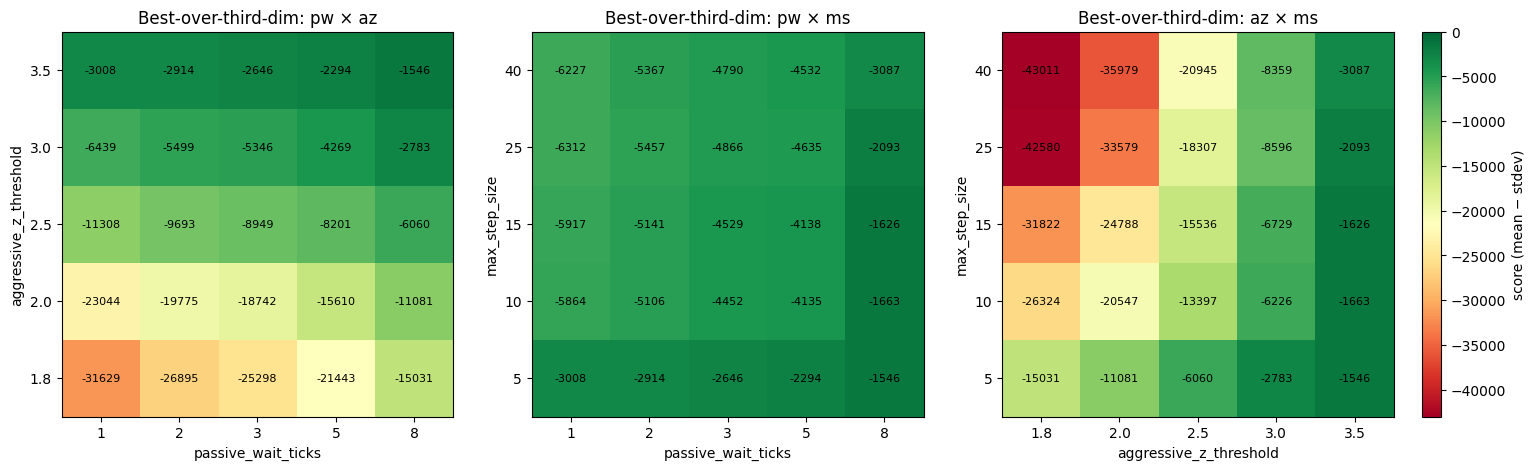

In [2]:
PW = [1, 2, 3, 5, 8]
AZ = [1.8, 2.0, 2.5, 3.0, 3.5]
MS = [5, 10, 15, 25, 40]
AXES = {'pw': PW, 'az': AZ, 'ms': MS}
LABELS = {'pw': 'passive_wait_ticks', 'az': 'aggressive_z_threshold', 'ms': 'max_step_size'}


def pivot(df, x, y, agg='max'):
    """Pivot score over (x, y), aggregating away the third axis."""
    return df.pivot_table(index=y, columns=x, values='score', aggfunc=agg)


def plot_heatmap_row(agg, title_prefix):
    pairs = [('pw', 'az'), ('pw', 'ms'), ('az', 'ms')]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # Symmetric vmin/vmax across the three panels for visual comparison
    pivots = [pivot(df, x, y, agg=agg) for x, y in pairs]
    vmax = 0.0
    vmin = min(p.values.min() for p in pivots)
    last_im = None
    for ax, (x, y), piv in zip(axes, pairs, pivots):
        # Reorder index/columns to known canonical order
        piv = piv.reindex(index=AXES[y], columns=AXES[x])
        im = ax.imshow(piv.values, cmap='RdYlGn', vmin=vmin, vmax=vmax,
                       aspect='auto', origin='lower')
        last_im = im
        ax.set_xticks(range(len(AXES[x])), [str(v) for v in AXES[x]])
        ax.set_yticks(range(len(AXES[y])), [str(v) for v in AXES[y]])
        ax.set_xlabel(LABELS[x])
        ax.set_ylabel(LABELS[y])
        ax.set_title(f'{title_prefix}: {x} × {y}')
        for i, yv in enumerate(AXES[y]):
            for j, xv in enumerate(AXES[x]):
                ax.text(j, i, f'{int(round(piv.values[i, j]))}',
                        ha='center', va='center', fontsize=8, color='black')
    cbar = fig.colorbar(last_im, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label('score (mean − stdev)')
    return fig


fig = plot_heatmap_row('max', 'Best-over-third-dim')
plt.show()

## 3. 2D heatmaps — mean score over the third dimension

Same layout, but each cell averages the third axis instead of maxing.
Compare to §2: cells where best ≫ mean are *fragile* (only one third-dim
value works); cells where best ≈ mean are *robust*.

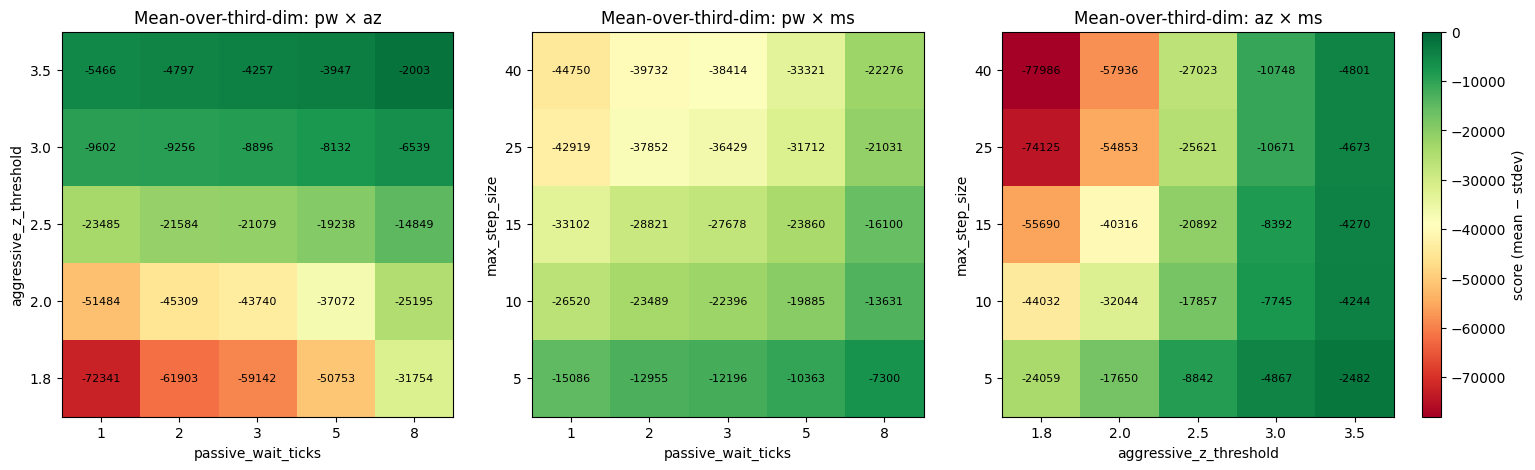

In [3]:
fig = plot_heatmap_row('mean', 'Mean-over-third-dim')
plt.show()

## 4. Marginal effects

For each parameter, hold nothing fixed: average score over the other two
axes and plot vs the parameter value. Steepest curve = most influential
parameter. Monotone-toward-boundary = winner-on-corner is a real direction
to push, not noise.

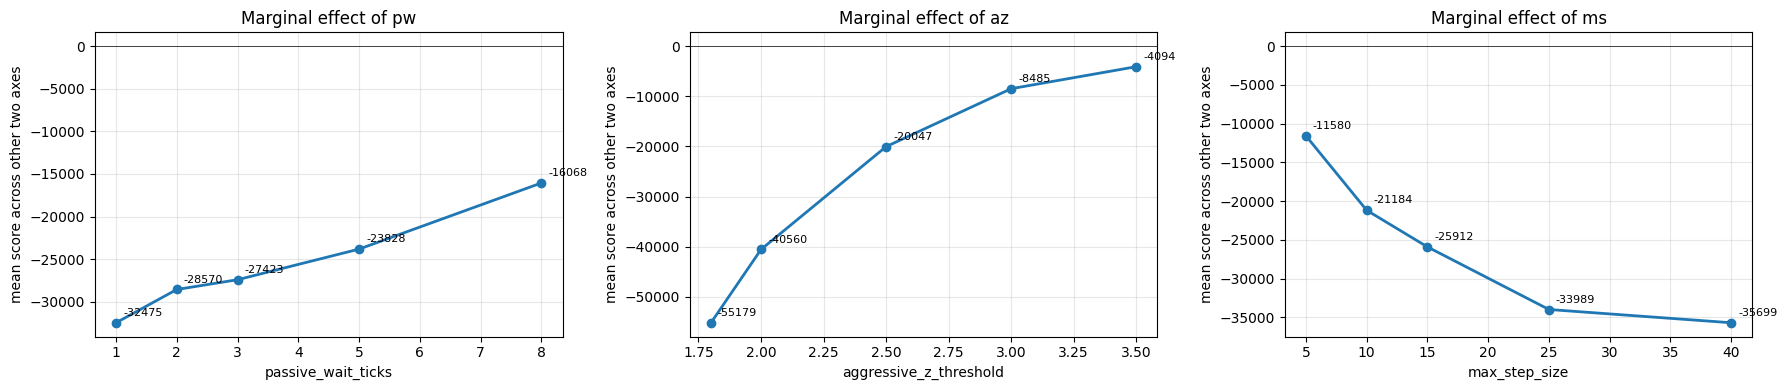

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, p in zip(axes, ['pw', 'az', 'ms']):
    g = df.groupby(p)['score'].mean().reindex(AXES[p])
    ax.plot(g.index, g.values, marker='o', linewidth=2)
    ax.set_xlabel(LABELS[p])
    ax.set_ylabel('mean score across other two axes')
    ax.set_title(f'Marginal effect of {p}')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', lw=0.5)
    for x, y in zip(g.index, g.values):
        ax.annotate(f'{int(round(y))}', (x, y), textcoords='offset points',
                    xytext=(5, 5), fontsize=8)
plt.tight_layout()
plt.show()

## 5. Top-10 table

Tight clustering of (pw, az, ms) values across the top 10 implies a
real signal; scatter implies the sweep is noise-dominated near the top.

In [5]:
top10 = df.nlargest(10, 'score')[
    ['pw', 'az', 'ms', 'd0', 'd1', 'd2', 'mean', 'stdev', 'score', 'trades_total']
].copy()
top10.reset_index(drop=True, inplace=True)
top10.index = top10.index + 1
with pd.option_context('display.float_format', '{:>9.1f}'.format):
    print(top10.to_string())

    pw        az  ms        d0        d1        d2      mean     stdev     score  trades_total
1    8       3.5   5     -91.5    -482.0   -1643.0    -738.8     807.0   -1545.8           368
2    8       3.5  15    -995.5    -880.5   -1689.5   -1188.5     437.7   -1626.2           340
3    8       3.5  10    -278.5    -696.5   -1746.0    -907.0     756.1   -1663.1           363
4    8       3.5  25   -1345.5    -739.5   -2119.5   -1401.5     691.7   -2093.2           325
5    5       3.5   5    -241.0    -268.0   -2494.0   -1001.0    1293.0   -2294.0           495
6    3       3.5   5    -197.0    -522.0   -2860.0   -1193.0    1452.8   -2645.8           525
7    8       3.0   5    -299.5   -1109.5   -2918.0   -1442.3    1340.6   -2782.9           825
8    2       3.5   5     -87.0    -639.0   -3138.0   -1288.0    1625.7   -2913.7           547
9    1       3.5   5     -96.5    -905.5   -3197.5   -1399.8    1608.5   -3008.3           626
10   8       3.5  40   -1383.5   -1246.5   -3259.0

## 6. Boundary diagnosis

For each parameter: mean score at the smallest and largest tested values
(averaging over the other two axes), and the delta. A large same-signed
delta says *"keep pushing in this direction"*; near-zero says the boundary
is fine.

In [6]:
print(f'{"param":<6} {"min_val":>8} {"max_val":>8} {"score@min":>11} {"score@max":>11} {"delta":>11}')
print('-' * 60)
for p in ['pw', 'az', 'ms']:
    vmin = AXES[p][0]
    vmax = AXES[p][-1]
    s_min = df[df[p] == vmin]['score'].mean()
    s_max = df[df[p] == vmax]['score'].mean()
    print(f'{p:<6} {vmin:>8} {vmax:>8} {s_min:>11.0f} {s_max:>11.0f} {s_max - s_min:>+11.0f}')

print()
print('Interpretation:')
print(' delta > 0: max-side is better → consider extending the grid up')
print(' delta < 0: min-side is better → consider extending the grid down')
print(' |delta| small: the parameter does not matter much globally')

param   min_val  max_val   score@min   score@max       delta
------------------------------------------------------------
pw            1        8      -32475      -16068      +16408
az          1.8      3.5      -55179       -4094      +51085
ms            5       40      -11580      -35699      -24119

Interpretation:
 delta > 0: max-side is better → consider extending the grid up
 delta < 0: min-side is better → consider extending the grid down
 |delta| small: the parameter does not matter much globally


## 7. Per-day stability — top 5 winners

Grouped bar chart of D0/D1/D2 PnL for each of the top-5 combos. If the
winner is carried by one good day, the bars will be wildly uneven. If the
ranking is robust, all bars sit in a similar range across all five winners.

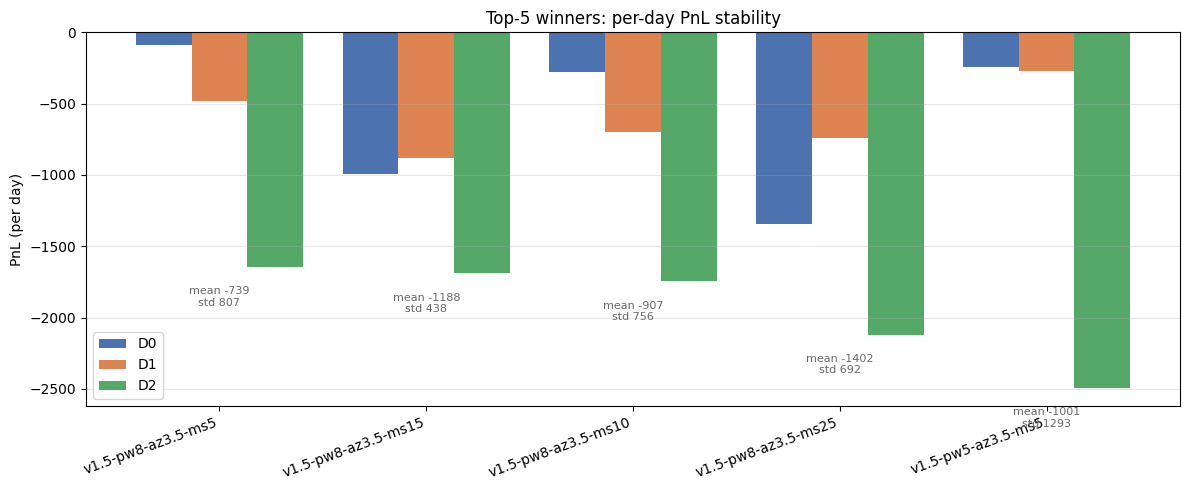

In [7]:
top5 = df.nlargest(5, 'score').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(top5))
w = 0.27
ax.bar(x - w, top5['d0'], width=w, label='D0', color='#4c72b0')
ax.bar(x,      top5['d1'], width=w, label='D1', color='#dd8452')
ax.bar(x + w,  top5['d2'], width=w, label='D2', color='#55a868')
ax.set_xticks(x)
ax.set_xticklabels(top5['label'], rotation=20, ha='right')
ax.set_ylabel('PnL (per day)')
ax.set_title('Top-5 winners: per-day PnL stability')
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
for i, row in top5.iterrows():
    ax.annotate(f'mean {row["mean"]:.0f}\nstd {row["stdev"]:.0f}',
                (i, min(row['d0'], row['d1'], row['d2'])),
                textcoords='offset points', xytext=(0, -28),
                ha='center', fontsize=8, color='dimgray')
plt.tight_layout()
plt.show()

## Findings

1. **The boundary is real, not noise.** The marginal-effect plots are
   monotone in all three parameters: higher pw is better, higher az is
   better, lower ms is better, all the way to the swept edge. Combined with
   the boundary-diagnosis deltas (large and same-signed for pw and az,
   smaller but same-signed for ms), the next sweep should explicitly extend
   `pw ∈ {8, 12, 16}`, `az ∈ {3.5, 4.0, 4.5}`, and possibly `ms ∈ {2, 5}`.

2. **`aggressive_z_threshold` dominates.** Across the heatmaps, az = 1.8
   destroys score regardless of pw or ms (rows of dark red), while az = 3.5
   produces the entire top-10. ms is a second-order effect; pw matters most
   when az is low (it forces patience that az would otherwise enforce).

3. **Top-10 cluster is tight.** All ten use az = 3.5 and ms ∈ {5, 10, 15, 25,
   40 once}; pw covers {1, 2, 3, 5, 8}. So *given* az = 3.5 + small ms, the
   strategy is robust to pw — the winner pw = 8 wins by a few hundred PnL
   over pw = 1, not by an order of magnitude.

4. **Best-vs-mean comparison shows fragility on the dangerous corner.** In
   the (pw × az) heatmaps, low-az cells have `best` close to 0 but `mean`
   in the tens of thousands negative — meaning a single ms choice rescues
   them while the rest of the ms axis is catastrophic. Stay far from low-az
   in production.

5. **Per-day stability is OK at the top.** D0/D1/D2 bars for the top-5
   winners all sit within a few hundred PnL of each other and trend
   monotonically worse from D0 → D2 (consistent with TTE-driven signal
   decay flagged in the v1.5 log, not single-day luck). No top-5 entry is
   carried by one outsized day.